# Comprehensive EDA: Polymer Property Dataset

Exploratory data analysis across 3 CSV files to understand:
- Dataset composition and profiles
- Feature distributions (local and global)
- SMILES overlap analysis
- Feature coverage
- Dataset contributions to property ranges
- Property correlations

In [1]:
# All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
from mlbag.config import MLBagConfig
from mlbag.tracking import RunManager

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [2]:
# Setup mlbag for experiment tracking
class EDAConfig(MLBagConfig):
    run_name: str = "eda-opp"
    experiment_name: str = "polymer-eda"
    description: str = "EDA of polymer property datasets"

config = EDAConfig()
rm = RunManager(base_dir="runs", run_id="eda-opp")
print(f"Run directory: {rm.run_dir}")

Run directory: runs/eda-opp


## 1. Load and Profile Datasets

In [3]:
# Load all datasets
datasets = {}
datasets['train'] = pd.read_csv('train.csv')
datasets['public'] = pd.read_csv('public.csv')
datasets['private'] = pd.read_csv('private.csv')

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
# Profile each dataset
def profile_dataset(name: str, df: pd.DataFrame) -> Dict:
    """Generate profile statistics for a dataset."""
    profile = {
        'name': name,
        'rows': len(df),
        'columns': df.shape[1],
        'column_names': list(df.columns),
        'dtypes': df.dtypes.to_dict(),
        'memory_mb': df.memory_usage(deep=True).sum() / 1024**2,
        'missing_pct': (df.isnull().sum() / len(df) * 100).to_dict(),
    }
    return profile

profiles = {name: profile_dataset(name, df) for name, df in datasets.items()}

# Display profiles as DataFrame
profile_summary = pd.DataFrame([
    {
        'Dataset': p['name'],
        'Rows': p['rows'],
        'Columns': p['columns'],
        'Column Names': ', '.join(p['column_names']),
        'Memory (MB)': f"{p['memory_mb']:.2f}"
    }
    for p in profiles.values()
])

print("\n=== DATASET PROFILES ===")
print(profile_summary.to_string(index=False))

# Save profile
profile_summary.to_csv(rm.run_dir / 'dataset_profiles.csv', index=False)


=== DATASET PROFILES ===
Dataset  Rows  Columns                         Column Names Memory (MB)
  train  7973        7 id, SMILES, Tg, FFV, Tc, Density, Rg        1.18
 public   295        6     SMILES, Tg, FFV, Tc, Density, Rg        0.04
private  3207        6     SMILES, Tg, FFV, Tc, Density, Rg        0.42


## 2. Dataset Characterization

Understanding what each dataset contains

In [5]:
# Characterize dataset contents
characterization = {
    'train': 'Labeled training data with id, SMILES, and 5 target properties (Tg, FFV, Tc, Density, Rg)',
    'public': 'Supplemental labeled data (no id) with all 5 properties',
    'private': 'Supplemental labeled data (no id) with all 5 properties',
}

print("\n=== DATASET CHARACTERIZATION ===")
for name, desc in characterization.items():
    print(f"\n{name}:")
    print(f"  {desc}")
    print(f"  Columns: {list(datasets[name].columns)}")
    print(f"  Shape: {datasets[name].shape}")


=== DATASET CHARACTERIZATION ===

train:
  Labeled training data with id, SMILES, and 5 target properties (Tg, FFV, Tc, Density, Rg)
  Columns: ['id', 'SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg']
  Shape: (7973, 7)

public:
  Supplemental labeled data (no id) with all 5 properties
  Columns: ['SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg']
  Shape: (295, 6)

private:
  Supplemental labeled data (no id) with all 5 properties
  Columns: ['SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg']
  Shape: (3207, 6)


## 3. Feature Distribution Analysis

Analyzing distributions for each property with statistics

In [6]:
# Define all properties to analyze
properties = ['Tg', 'FFV', 'Tc', 'Density', 'Rg']

# Collect property data from each dataset
property_sources = {
    'Tg': ['train', 'public', 'private'],
    'FFV': ['train', 'public', 'private'],
    'Tc': ['train', 'public', 'private'],
    'Density': ['train', 'public', 'private'],
    'Rg': ['train', 'public', 'private'],
}

def calculate_property_stats(prop: str, sources: List[str]) -> pd.DataFrame:
    """Calculate statistics for a property across datasets."""
    stats_list = []
    
    for source in sources:
        df = datasets[source]
        if prop in df.columns:
            data = df[prop].dropna()
            if len(data) > 0:
                stats = {
                    'Dataset': source,
                    'Property': prop,
                    'Count': len(data),
                    'Mean': data.mean(),
                    'Std': data.std(),
                    'Min': data.min(),
                    'Q25': data.quantile(0.25),
                    'Median': data.median(),
                    'Q75': data.quantile(0.75),
                    'Max': data.max(),
                }
                stats_list.append(stats)
    
    return pd.DataFrame(stats_list)

# Calculate statistics for all properties
all_stats = []
for prop, sources in property_sources.items():
    stats_df = calculate_property_stats(prop, sources)
    all_stats.append(stats_df)

local_stats = pd.concat(all_stats, ignore_index=True)

print("\n=== LOCAL FEATURE STATISTICS (Per Dataset) ===")
for prop in properties:
    prop_stats = local_stats[local_stats['Property'] == prop]
    if len(prop_stats) > 0:
        print(f"\n{prop}:")
        print(prop_stats.to_string(index=False))

# Save local statistics
local_stats.to_csv(rm.run_dir / 'local_feature_statistics.csv', index=False)


=== LOCAL FEATURE STATISTICS (Per Dataset) ===

Tg:
Dataset Property  Count       Mean        Std         Min       Q25     Median        Q75      Max
  train       Tg    511  96.452314 111.228279 -148.029738 13.674509  74.040183 161.147595 472.2500
 public       Tg     95 102.884029 103.661929 -138.802100 38.159850  97.763900 169.928450 359.0841
private       Tg    166 179.820723 134.902469  -86.650000 60.397500 169.670000 285.332500 484.6900

FFV:
Dataset Property  Count     Mean      Std      Min      Q25   Median     Q75      Max
  train      FFV   7030 0.367212 0.029609 0.226992 0.349549 0.364264 0.38079 0.777097
 public      FFV     86 0.357942 0.038891 0.315000 0.337250 0.352500 0.37000 0.656000
private      FFV    137 0.356066 0.023907 0.306000 0.342000 0.351000 0.36600 0.454000

Tc:
Dataset Property  Count     Mean      Std      Min      Q25   Median      Q75   Max
  train       Tc    737 0.256334 0.089538 0.046500 0.186000 0.236000 0.330500 0.524
 public       Tc    239 0.25

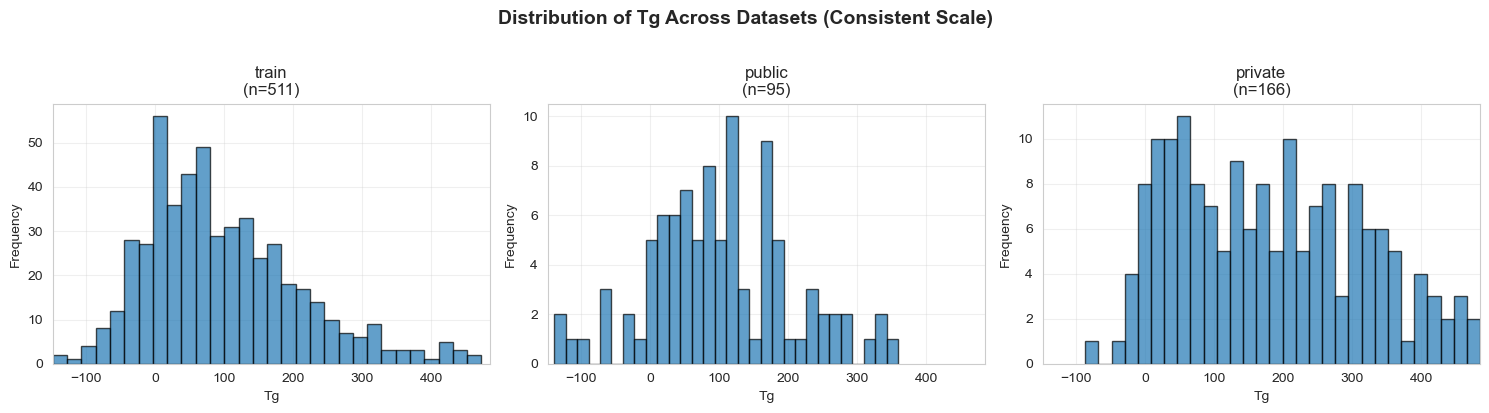

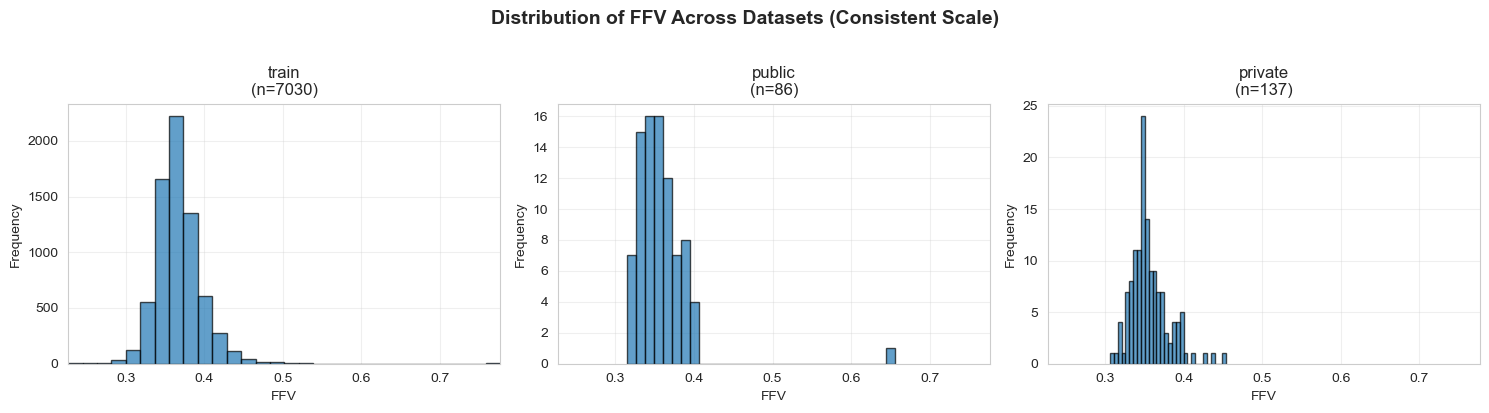

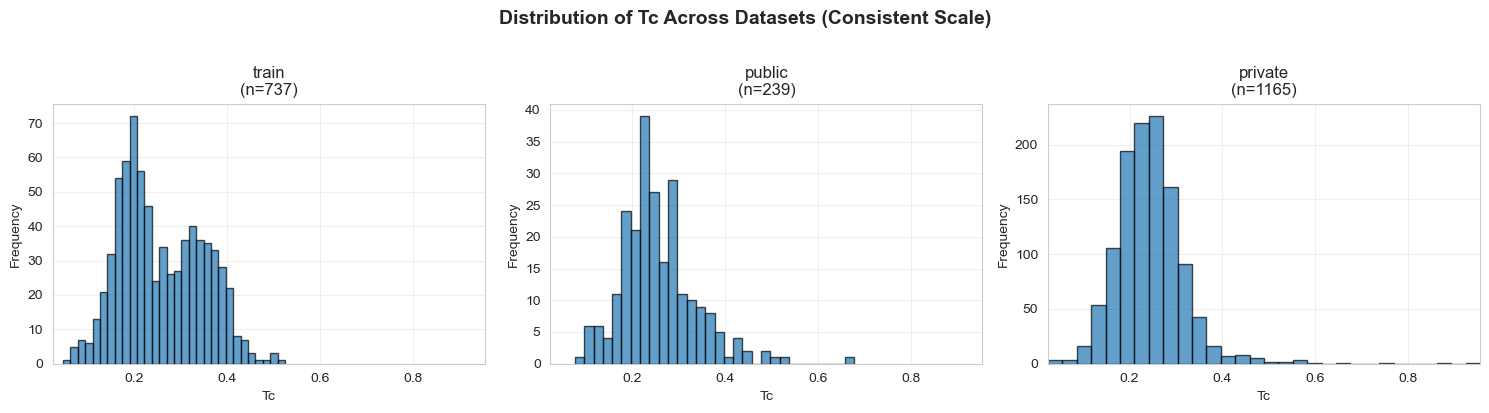

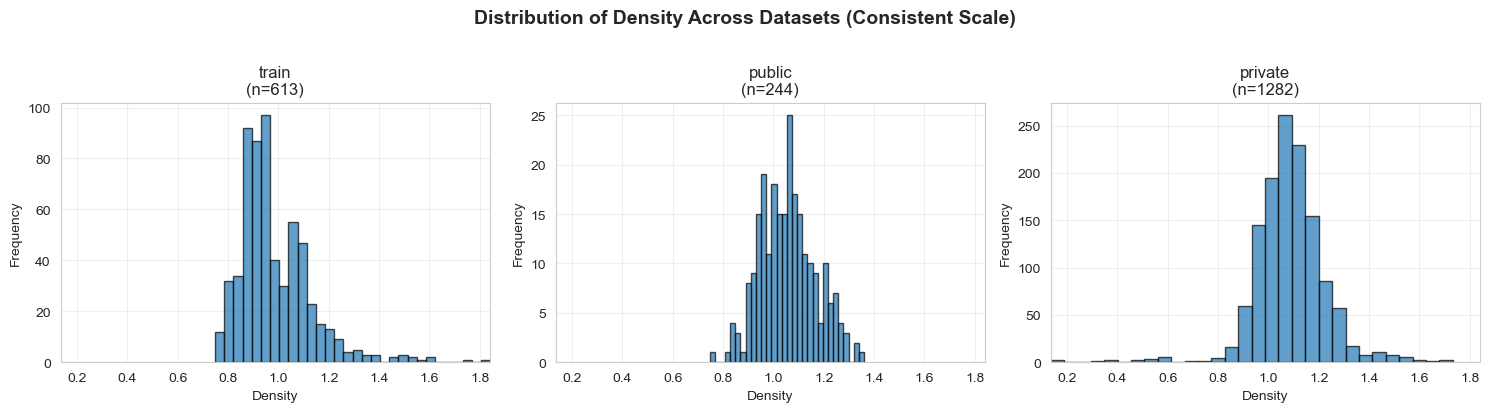

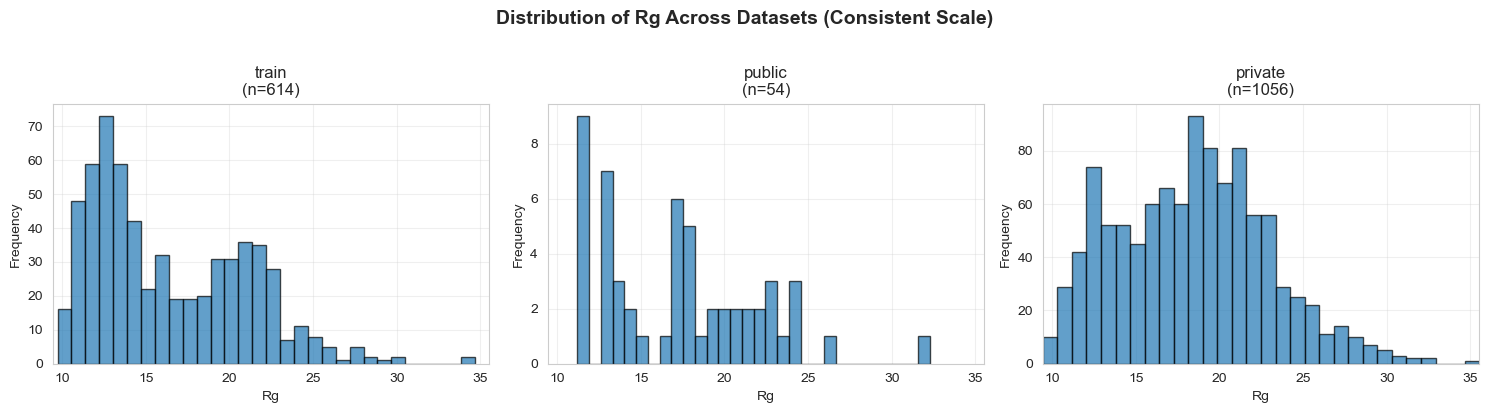

In [7]:
# Visualize distributions per dataset with consistent scales
def plot_property_distributions(prop: str, sources: List[str]):
    """Plot distributions for a property across datasets with consistent scale."""
    # Collect all data to determine global scale
    all_data = []
    for source in sources:
        df = datasets[source]
        if prop in df.columns:
            data = df[prop].dropna()
            if len(data) > 0:
                all_data.extend(data.values)
    
    if not all_data:
        return
    
    # Determine consistent scale
    global_min, global_max = np.min(all_data), np.max(all_data)
    
    # Create subplots
    n_sources = len([s for s in sources if prop in datasets[s].columns])
    fig, axes = plt.subplots(1, n_sources, figsize=(5*n_sources, 4))
    if n_sources == 1:
        axes = [axes]
    
    ax_idx = 0
    for source in sources:
        df = datasets[source]
        if prop in df.columns:
            data = df[prop].dropna()
            if len(data) > 0:
                ax = axes[ax_idx]
                ax.hist(data, bins=30, alpha=0.7, edgecolor='black')
                ax.set_xlim(global_min, global_max)
                ax.set_title(f'{source}\n(n={len(data)})')
                ax.set_xlabel(prop)
                ax.set_ylabel('Frequency')
                ax.grid(alpha=0.3)
                ax_idx += 1
    
    plt.suptitle(f'Distribution of {prop} Across Datasets (Consistent Scale)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    fig_path = rm.run_dir / f'distribution_{prop}.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

# Generate distribution plots for all properties
for prop, sources in property_sources.items():
    plot_property_distributions(prop, sources)

## 4. SMILES Overlap Analysis

Analyzing overlap between datasets by unique SMILES

In [8]:
# Extract SMILES from each dataset
smiles_data = {}
for name, df in datasets.items():
    if 'SMILES' in df.columns:
        smiles_data[name] = df['SMILES'].dropna().tolist()

# Calculate overlap statistics
overlap_stats = []
for name, smiles_list in smiles_data.items():
    total = len(smiles_list)
    unique = len(set(smiles_list))
    pct_unique = (unique / total * 100) if total > 0 else 0
    
    overlap_stats.append({
        'Dataset': name,
        'Total SMILES': total,
        'Unique SMILES': unique,
        '% Unique': f"{pct_unique:.2f}%"
    })

overlap_df = pd.DataFrame(overlap_stats)
print("\n=== SMILES OVERLAP ANALYSIS ===")
print(overlap_df.to_string(index=False))

# Calculate global unique SMILES
all_smiles = []
for smiles_list in smiles_data.values():
    all_smiles.extend(smiles_list)

global_unique = len(set(all_smiles))
global_total = len(all_smiles)

print(f"\nGlobal Statistics:")
print(f"  Total SMILES across all datasets: {global_total:,}")
print(f"  Unique SMILES across all datasets: {global_unique:,}")
print(f"  Overall % Unique: {(global_unique/global_total*100):.2f}%")

# Save overlap statistics
overlap_df.to_csv(rm.run_dir / 'smiles_overlap_stats.csv', index=False)


=== SMILES OVERLAP ANALYSIS ===
Dataset  Total SMILES  Unique SMILES % Unique
  train          7973           7973  100.00%
 public           295            295  100.00%
private          3207           3207  100.00%

Global Statistics:
  Total SMILES across all datasets: 11,475
  Unique SMILES across all datasets: 11,475
  Overall % Unique: 100.00%


In [9]:
# Build SMILES occurrence matrix
unique_smiles = set(all_smiles)
print(f"\nBuilding occurrence matrix for {len(unique_smiles):,} unique SMILES...")

# For efficiency, we'll analyze which datasets each SMILES appears in
smiles_occurrence = {}
for smiles in unique_smiles:
    datasets_present = [name for name, smiles_list in smiles_data.items() if smiles in smiles_list]
    smiles_occurrence[smiles] = datasets_present

# Count SMILES appearing in multiple datasets
multi_dataset_count = sum(1 for datasets_list in smiles_occurrence.values() if len(datasets_list) > 1)
print(f"SMILES appearing in multiple datasets: {multi_dataset_count:,} ({multi_dataset_count/len(unique_smiles)*100:.2f}%)")

# Distribution of SMILES across datasets
occurrence_dist = pd.Series([len(datasets_list) for datasets_list in smiles_occurrence.values()]).value_counts().sort_index()
print("\nDistribution of SMILES across datasets:")
for n_datasets, count in occurrence_dist.items():
    print(f"  {n_datasets} dataset(s): {count:,} SMILES ({count/len(unique_smiles)*100:.2f}%)")


Building occurrence matrix for 11,475 unique SMILES...
SMILES appearing in multiple datasets: 0 (0.00%)

Distribution of SMILES across datasets:
  1 dataset(s): 11,475 SMILES (100.00%)



=== PAIRWISE OVERLAP PERCENTAGES ===
(% of row dataset's SMILES that also appear in column dataset)
         train  public  private
train    100.0     0.0      0.0
public     0.0   100.0      0.0
private    0.0     0.0    100.0


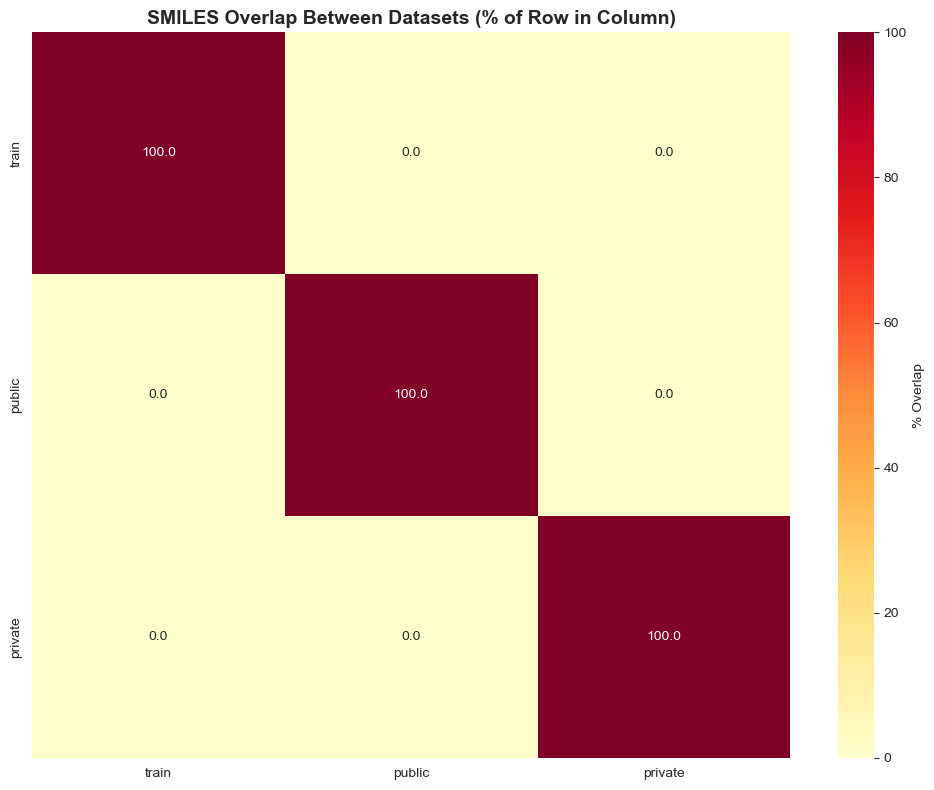

In [10]:
# Calculate pairwise overlap percentages
dataset_names = list(smiles_data.keys())
overlap_matrix = pd.DataFrame(0.0, index=dataset_names, columns=dataset_names)

for i, name1 in enumerate(dataset_names):
    set1 = set(smiles_data[name1])
    for name2 in dataset_names:
        set2 = set(smiles_data[name2])
        overlap = len(set1 & set2)
        pct = (overlap / len(set1) * 100) if len(set1) > 0 else 0
        overlap_matrix.loc[name1, name2] = pct

print("\n=== PAIRWISE OVERLAP PERCENTAGES ===")
print("(% of row dataset's SMILES that also appear in column dataset)")
print(overlap_matrix.round(2))

# Visualize overlap matrix
plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': '% Overlap'}, vmin=0, vmax=100)
plt.title('SMILES Overlap Between Datasets (% of Row in Column)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(rm.run_dir / 'smiles_overlap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

overlap_matrix.to_csv(rm.run_dir / 'pairwise_overlap_matrix.csv')

## 5. Feature Coverage Analysis

Understanding which properties are available in which datasets

In [11]:
# Create feature coverage matrix
coverage_matrix = pd.DataFrame(index=list(datasets.keys()), columns=properties)

for name, df in datasets.items():
    for prop in properties:
        if prop in df.columns:
            n_values = df[prop].notna().sum()
            coverage_matrix.loc[name, prop] = n_values
        else:
            coverage_matrix.loc[name, prop] = 0

coverage_matrix = coverage_matrix.fillna(0).astype(int)

print("\n=== FEATURE COVERAGE MATRIX ===")
print("(Number of non-null measurements per property per dataset)")
print(coverage_matrix)

# Calculate missingness rates
missingness = pd.DataFrame(index=list(datasets.keys()), columns=properties)

for name, df in datasets.items():
    for prop in properties:
        if prop in df.columns:
            missing_pct = (df[prop].isna().sum() / len(df) * 100)
            missingness.loc[name, prop] = f"{missing_pct:.1f}%"
        else:
            missingness.loc[name, prop] = "N/A"

print("\n=== MISSINGNESS RATES ===")
print(missingness)

# Save coverage data
coverage_matrix.to_csv(rm.run_dir / 'feature_coverage_matrix.csv')
missingness.to_csv(rm.run_dir / 'feature_missingness_rates.csv')


=== FEATURE COVERAGE MATRIX ===
(Number of non-null measurements per property per dataset)
          Tg   FFV    Tc  Density    Rg
train    511  7030   737      613   614
public    95    86   239      244    54
private  166   137  1165     1282  1056

=== MISSINGNESS RATES ===
            Tg    FFV     Tc Density     Rg
train    93.6%  11.8%  90.8%   92.3%  92.3%
public   67.8%  70.8%  19.0%   17.3%  81.7%
private  94.8%  95.7%  63.7%   60.0%  67.1%


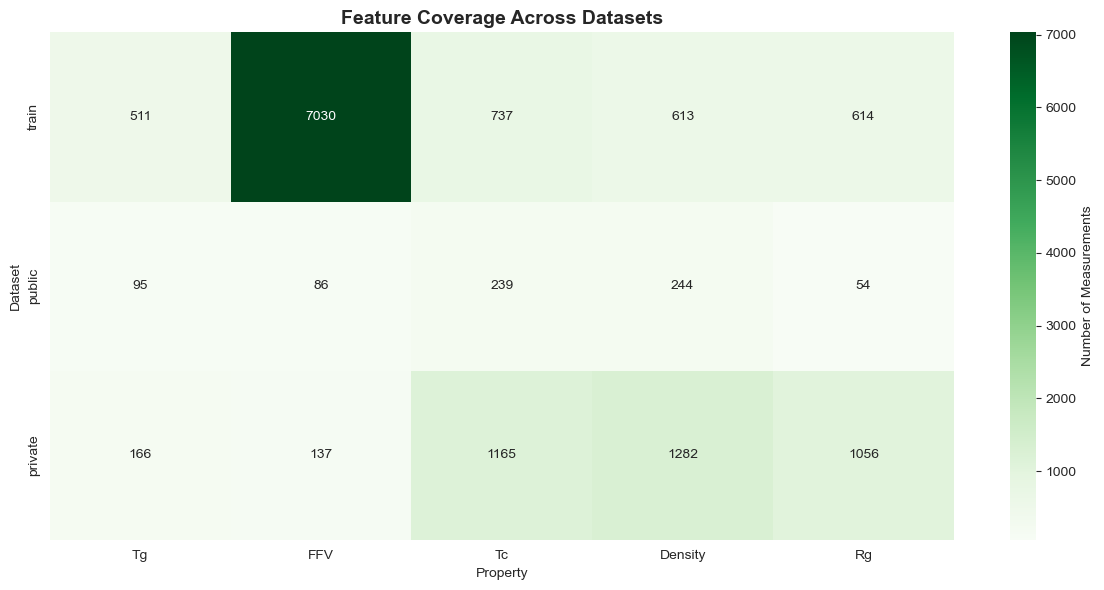


=== TOTAL MEASUREMENTS PER PROPERTY ===
  FFV: 7,253
  Tc: 2,141
  Density: 2,139
  Rg: 1,724
  Tg: 772


In [12]:
# Visualize feature coverage
plt.figure(figsize=(12, 6))
sns.heatmap(coverage_matrix, annot=True, fmt='d', cmap='Greens', 
            cbar_kws={'label': 'Number of Measurements'})
plt.title('Feature Coverage Across Datasets', fontsize=14, fontweight='bold')
plt.xlabel('Property')
plt.ylabel('Dataset')
plt.tight_layout()
plt.savefig(rm.run_dir / 'feature_coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Total measurements per property
total_measurements = coverage_matrix.sum(axis=0).sort_values(ascending=False)
print("\n=== TOTAL MEASUREMENTS PER PROPERTY ===")
for prop, count in total_measurements.items():
    print(f"  {prop}: {count:,}")

## 6. Global Aggregated Views

Combining all datasets for global statistics and visualizations

In [13]:
# Combine all datasets with properties into unified DataFrame
combined_data = []

for name, df in datasets.items():
    if 'SMILES' in df.columns:
        df_copy = df.copy()
        df_copy['source'] = name
        combined_data.append(df_copy)

unified_df = pd.concat(combined_data, ignore_index=True)
print(f"\nUnified dataset shape: {unified_df.shape}")
print(f"Columns: {list(unified_df.columns)}")


Unified dataset shape: (11475, 8)
Columns: ['id', 'SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg', 'source']


In [14]:
# Calculate global statistics for each property
global_stats = []

for prop in properties:
    if prop in unified_df.columns:
        data = unified_df[prop].dropna()
        if len(data) > 0:
            stats = {
                'Property': prop,
                'Count': len(data),
                'Mean': data.mean(),
                'Std': data.std(),
                'Min': data.min(),
                'Q25': data.quantile(0.25),
                'Median': data.median(),
                'Q75': data.quantile(0.75),
                'Max': data.max(),
            }
            global_stats.append(stats)

global_stats_df = pd.DataFrame(global_stats)

print("\n=== GLOBAL FEATURE STATISTICS (All Sources Combined) ===")
print(global_stats_df.to_string(index=False))

# Save global statistics
global_stats_df.to_csv(rm.run_dir / 'global_feature_statistics.csv', index=False)


=== GLOBAL FEATURE STATISTICS (All Sources Combined) ===
Property  Count       Mean        Std         Min       Q25    Median        Q75        Max
      Tg    772 115.170149 120.578325 -148.029738 25.983490 88.670579 182.689382 484.690000
     FFV   7253   0.366892   0.029689    0.226992  0.349115  0.363999   0.380500   0.777097
      Tc   2141   0.250415   0.082257    0.024488  0.196000  0.239656   0.296000   0.954000
 Density   2139   1.054006   0.146605    0.134543  0.959558  1.053194   1.134300   1.840999
      Rg   1724  17.650495   4.657384    9.445485 13.459012 17.610008  21.038175  35.529550


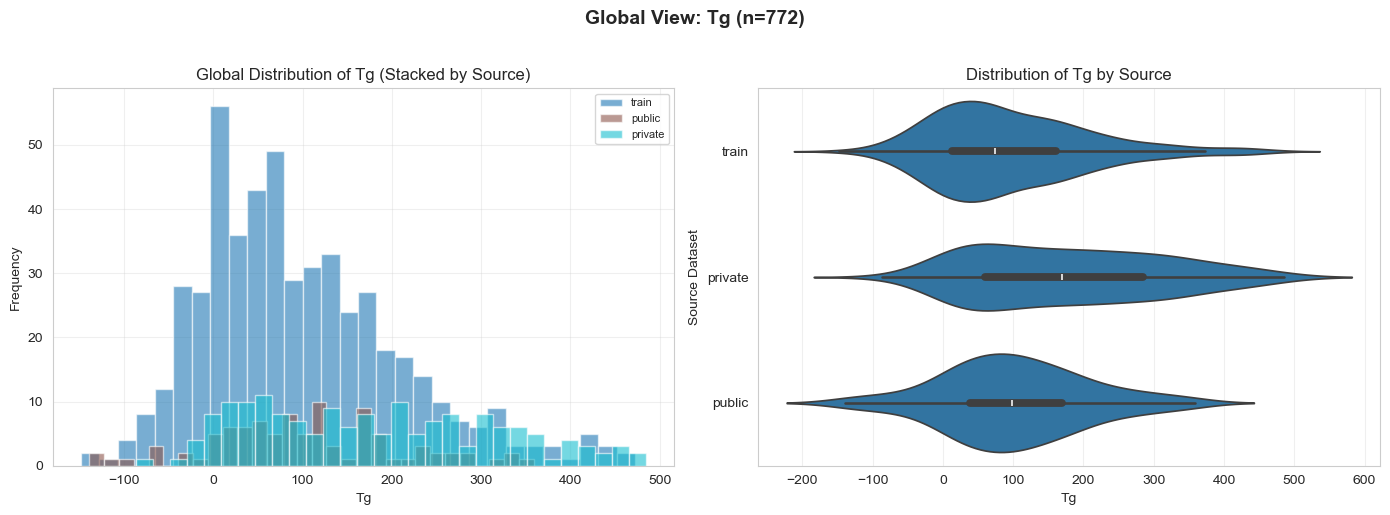

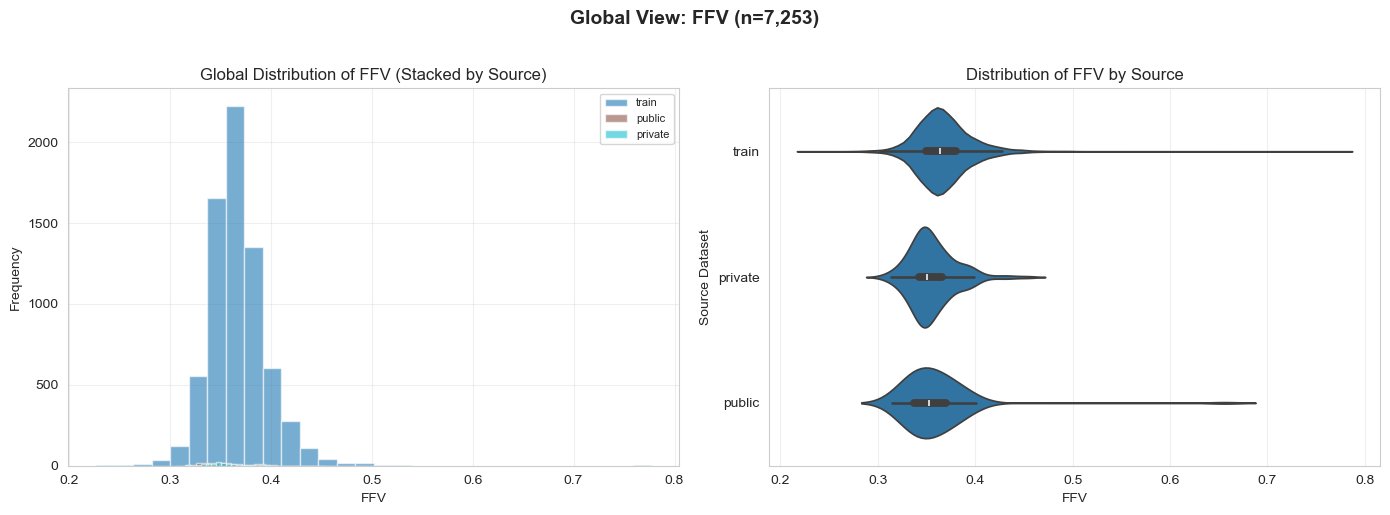

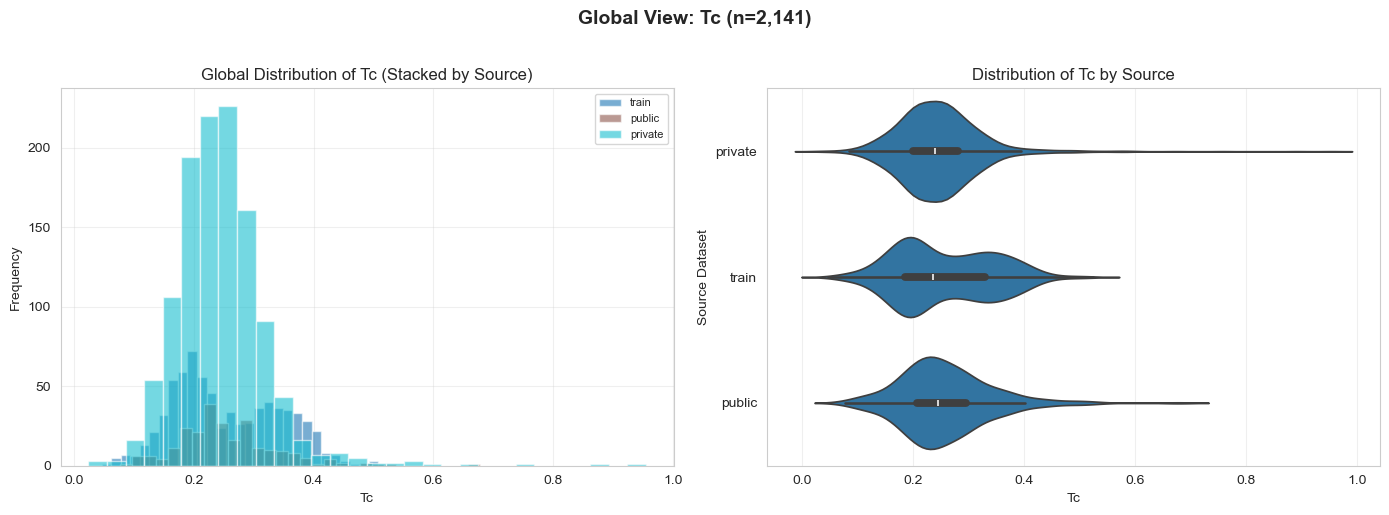

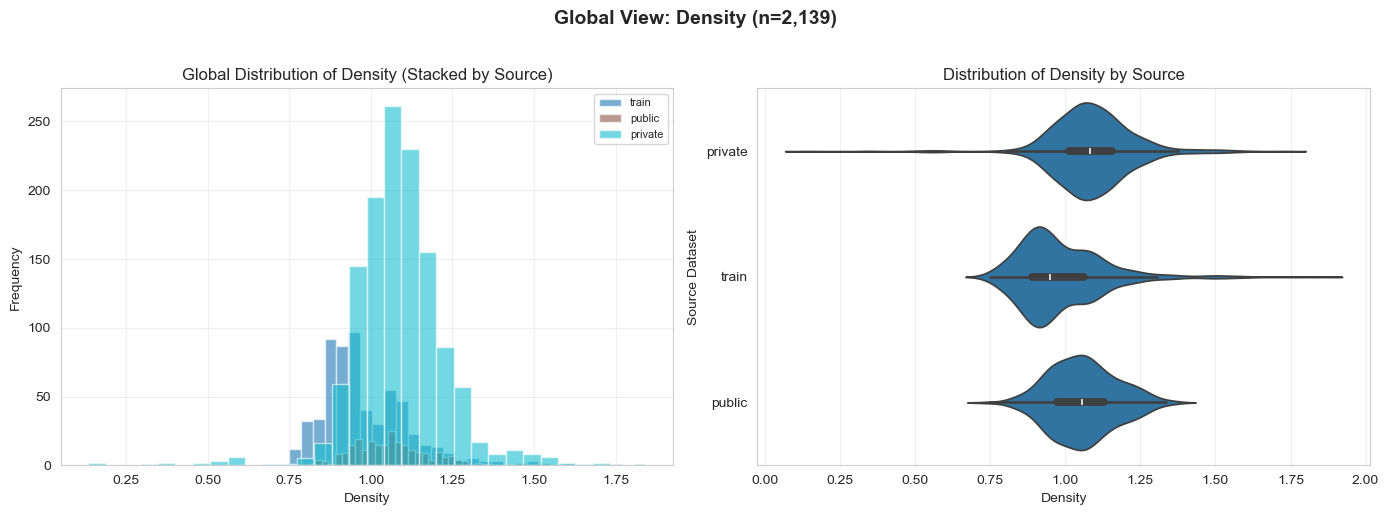

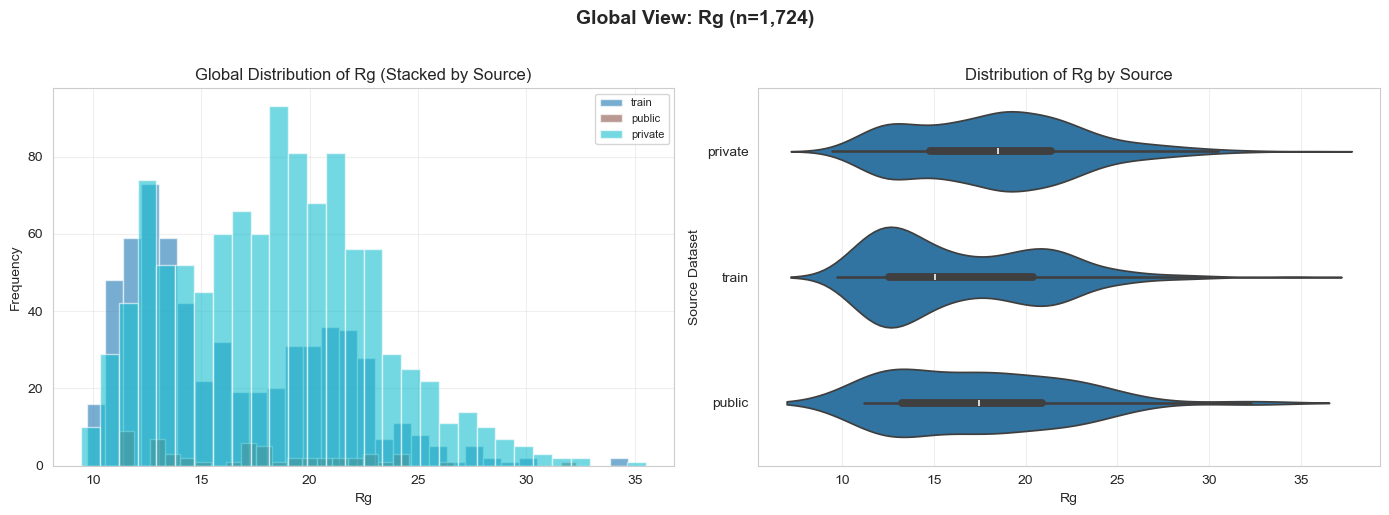

In [15]:
# Global distribution plots with dataset contribution
def plot_global_distribution_with_sources(prop: str):
    """Plot global distribution showing contribution from each dataset."""
    if prop not in unified_df.columns:
        return
    
    # Filter data
    plot_data = unified_df[['source', prop]].dropna()
    if len(plot_data) == 0:
        return
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Stacked histogram
    sources = plot_data['source'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(sources)))
    
    for i, source in enumerate(sources):
        source_data = plot_data[plot_data['source'] == source][prop]
        ax1.hist(source_data, bins=30, alpha=0.6, label=source, color=colors[i])
    
    ax1.set_xlabel(prop)
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'Global Distribution of {prop} (Stacked by Source)')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(alpha=0.3)
    
    # Right: Violin plot by source
    source_order = plot_data.groupby('source')[prop].count().sort_values(ascending=False).index
    sns.violinplot(data=plot_data, y='source', x=prop, order=source_order, ax=ax2)
    ax2.set_title(f'Distribution of {prop} by Source')
    ax2.set_xlabel(prop)
    ax2.set_ylabel('Source Dataset')
    ax2.grid(alpha=0.3, axis='x')
    
    plt.suptitle(f'Global View: {prop} (n={len(plot_data):,})', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    fig_path = rm.run_dir / f'global_distribution_{prop}.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

# Generate global distribution plots for all properties
for prop in properties:
    plot_global_distribution_with_sources(prop)


=== DATASET CONTRIBUTION BREAKDOWN ===
Property  Density   FFV    Rg    Tc   Tg
Source                                  
private      1282   137  1056  1165  166
public        244    86    54   239   95
train         613  7030   614   737  511


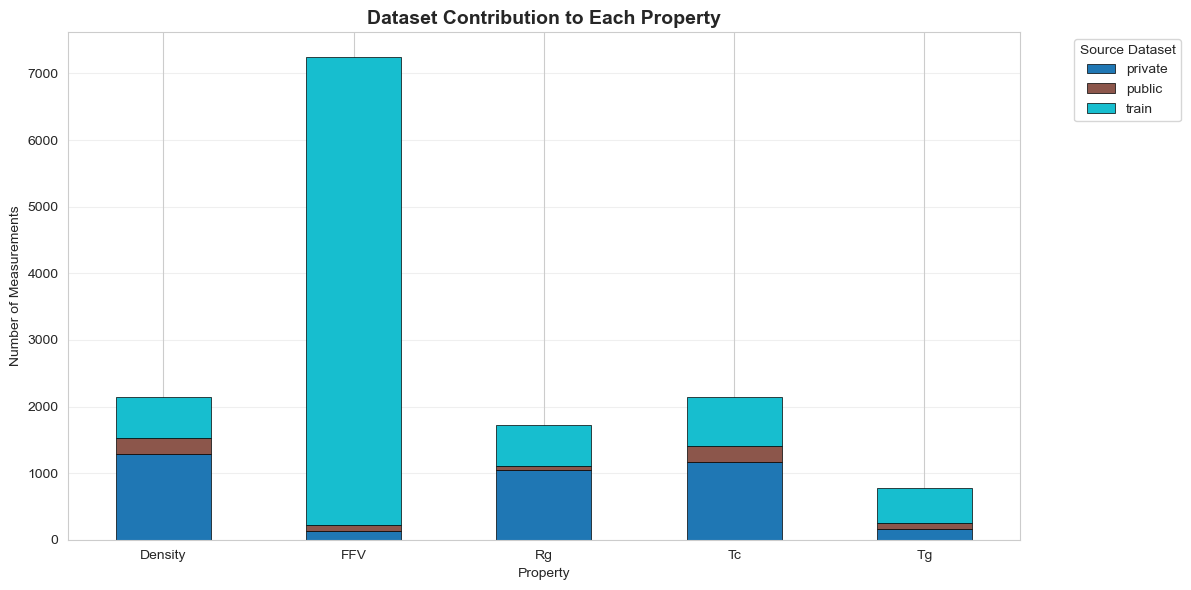

In [16]:
# Dataset contribution breakdown
contribution = []
for prop in properties:
    if prop in unified_df.columns:
        prop_contribution = unified_df.groupby('source')[prop].count().to_dict()
        for source, count in prop_contribution.items():
            contribution.append({
                'Property': prop,
                'Source': source,
                'Measurements': count
            })

contribution_df = pd.DataFrame(contribution)
contribution_pivot = contribution_df.pivot(index='Source', columns='Property', values='Measurements').fillna(0).astype(int)

print("\n=== DATASET CONTRIBUTION BREAKDOWN ===")
print(contribution_pivot)

# Visualize contribution
plt.figure(figsize=(12, 6))
contribution_pivot.T.plot(kind='bar', stacked=True, ax=plt.gca(), 
                          colormap='tab10', edgecolor='black', linewidth=0.5)
plt.title('Dataset Contribution to Each Property', fontsize=14, fontweight='bold')
plt.xlabel('Property')
plt.ylabel('Number of Measurements')
plt.legend(title='Source Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(rm.run_dir / 'dataset_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

contribution_pivot.to_csv(rm.run_dir / 'dataset_contribution_breakdown.csv')


=== PROPERTY-PROPERTY CORRELATION MATRIX ===
            Tg    FFV     Tc  Density     Rg
Tg       1.000  0.022 -0.073    0.376  0.207
FFV      0.022  1.000  0.109   -0.295 -0.088
Tc      -0.073  0.109  1.000   -0.327  0.503
Density  0.376 -0.295 -0.327    1.000  0.210
Rg       0.207 -0.088  0.503    0.210  1.000


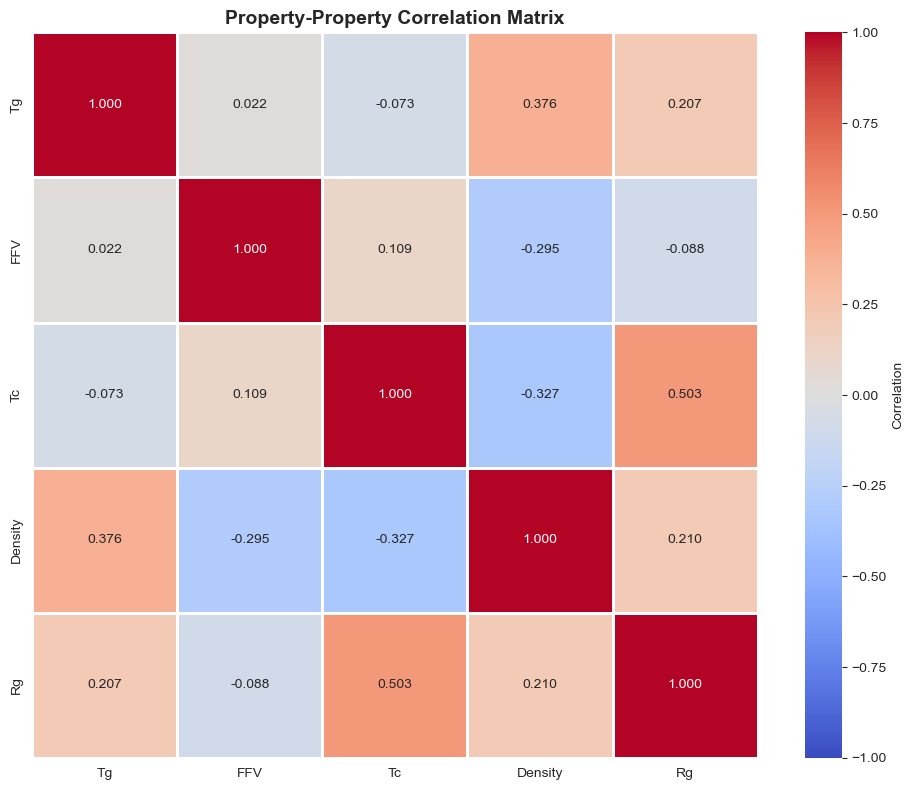

In [17]:
# Property-property correlation matrix
# Only include properties with measurements
available_props = [prop for prop in properties if prop in unified_df.columns and unified_df[prop].notna().sum() > 0]

# Calculate correlations
corr_matrix = unified_df[available_props].corr()

print("\n=== PROPERTY-PROPERTY CORRELATION MATRIX ===")
print(corr_matrix.round(3))

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Property-Property Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(rm.run_dir / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

corr_matrix.to_csv(rm.run_dir / 'property_correlation_matrix.csv')

In [18]:
# Global summary table
summary_data = {
    'Metric': [
        'Total Datasets',
        'Total SMILES (with duplicates)',
        'Unique SMILES',
        'Properties Tracked',
    ],
    'Value': [
        len(datasets),
        f"{global_total:,}",
        f"{global_unique:,}",
        len(properties),
    ]
}

# Add property measurements
for prop in properties:
    count = total_measurements.get(prop, 0)
    summary_data['Metric'].append(f'{prop} measurements')
    summary_data['Value'].append(f"{count:,}")

summary_df = pd.DataFrame(summary_data)

print("\n=== GLOBAL SUMMARY ===")
print(summary_df.to_string(index=False))

summary_df.to_csv(rm.run_dir / 'global_summary.csv', index=False)


=== GLOBAL SUMMARY ===
                        Metric  Value
                Total Datasets      3
Total SMILES (with duplicates) 11,475
                 Unique SMILES 11,475
            Properties Tracked      5
               Tg measurements    772
              FFV measurements  7,253
               Tc measurements  2,141
          Density measurements  2,139
               Rg measurements  1,724


## 7. Summary Report

In [19]:
print("\n" + "="*80)
print("EDA SUMMARY REPORT")
print("="*80)

print("\n1. DATASET OVERVIEW")
print(f"   - Total datasets analyzed: {len(datasets)}")
print(f"   - Total SMILES entries: {global_total:,}")
print(f"   - Unique SMILES: {global_unique:,} ({global_unique/global_total*100:.2f}% unique)")

print("\n2. FEATURE COVERAGE")
print(f"   - Properties tracked: {len(properties)}")
for prop in properties:
    count = total_measurements.get(prop, 0)
    if count > 0:
        print(f"   - {prop}: {count:,} measurements")
    else:
        print(f"   - {prop}: No measurements")

print("\n3. KEY FINDINGS")
print(f"   - SMILES appearing in multiple datasets: {multi_dataset_count:,}")
print(f"   - Datasets with most measurements: {coverage_matrix.sum(axis=1).idxmax()}")
print(f"   - Most measured property: {total_measurements.idxmax()} ({total_measurements.max():,} measurements)")
print(f"   - Least measured property: {total_measurements.idxmin()} ({total_measurements.min():,} measurements)")

print("\n4. ARTIFACTS SAVED")
print(f"   - Run directory: {rm.run_dir}")
print("   - CSV exports: 9 files (profiles, statistics, coverage, contributions)")
print("   - Visualizations: 15+ plots (distributions, heatmaps, correlations)")

print("\n" + "="*80)
print("EDA COMPLETE!")
print("="*80)


EDA SUMMARY REPORT

1. DATASET OVERVIEW
   - Total datasets analyzed: 3
   - Total SMILES entries: 11,475
   - Unique SMILES: 11,475 (100.00% unique)

2. FEATURE COVERAGE
   - Properties tracked: 5
   - Tg: 772 measurements
   - FFV: 7,253 measurements
   - Tc: 2,141 measurements
   - Density: 2,139 measurements
   - Rg: 1,724 measurements

3. KEY FINDINGS
   - SMILES appearing in multiple datasets: 0
   - Datasets with most measurements: train
   - Most measured property: FFV (7,253 measurements)
   - Least measured property: Tg (772 measurements)

4. ARTIFACTS SAVED
   - Run directory: runs/eda-opp
   - CSV exports: 9 files (profiles, statistics, coverage, contributions)
   - Visualizations: 15+ plots (distributions, heatmaps, correlations)

EDA COMPLETE!
